# Введение в Machine Learning
 Практические задания на основе набора данных Iris и Intel® oneAPI AI Analytics Toolkit (AI Kit).

### Упражнение 1: Загрузка и первичный анализ данных
    Используя библиотеки `pandas` и `numpy`, загрузите файл `Iris_Data.csv` из директории `data`. Выведите на экран:
    - Общее количество строк.
    - Имена всех колонок.
    - Типы данных для каждой колонки.

In [1]:
import os
import numpy as np
import pandas as pd

# данные лежат в папке datasets в корне проекта
data_path = ['..', '..', '..', 'datasets']
filepath = os.sep.join(data_path + ['Iris_Data.csv'])
data = pd.read_csv(filepath)
print("Общее количество строк:", len(data))
print("Имена всех колонок:", list(data.columns))
print("Типы данных для каждой колонки:")
data.dtypes

Общее количество строк: 150
Имена всех колонок: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Типы данных для каждой колонки:


sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

### Упражнение 2: Очистка и преобразование текстовых данных
    Исследуйте значения в колонке `species`.
    Обратите внимание, что все они начинаются с префикса `Iris-`.
    Напишите код для удаления этого префикса во всех строках (чтобы осталось только `setosa`, `versicolor`, `virginica`).

In [2]:
data['species'] = data.species.str.replace('Iris-', '')
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Упражнение 3: Описательная статистика и размах (range)
    Используя метод `describe()`,
    создайте новую строку в таблице под названием `range`,
    которая вычисляет разницу между максимальным
    и минимальным значением для каждого числового столбца.

In [3]:
stats = data.describe()
stats.loc['range'] = stats.loc['max'] - stats.loc['min']
stats

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000
range,3.600000,2.400000,5.900000,2.400000


### Упражнение 4: Группировка данных по видам (Среднее и Медиана)
    "Сгруппируйте набор данных по колонке `species`
    и одновременно примените функции **среднего** (`mean`)
    и **медианы** (`median`) ко всем числовым колонкам.

In [4]:
data.groupby('species').agg(['mean', 'median'])

sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

### Упражнение 5: Расширенная агрегация с помощью словаря
    Используя метод `agg()` для сгруппированных данных,
    примените следующие правила: для `sepal_length`, `sepal_width` и `petal_width`
    вычислите среднее и медиану, а для `petal_length` — только максимальное значение (`max`).

In [5]:
data.groupby('species').agg({
    'sepal_length': ['mean', 'median'],
    'sepal_width': ['mean', 'median'],
    'petal_width': ['mean', 'median'],
    'petal_length': 'max',
})

sepal_length        sepal_width        petal_width         \
                   mean median        mean median        mean median   
species                                                                
setosa            5.006    5.0       3.418    3.4       0.244    0.2   
versicolor        5.936    5.9       2.770    2.8       1.326    1.3   
virginica         6.588    6.5       2.974    3.0       2.026    2.0   

           petal_length  
                    max  
species                  
setosa              1.9  
versicolor          5.1  
virginica           6.9

### Упражнение 6: Визуализация данных с помощью Matplotlib
    Импортируйте `matplotlib.pyplot`
    и постройте диаграмму рассеяния (scatter plot),
    отражающую зависимость `sepal_length` (ось X) от `sepal_width` (ось Y).
    Добавьте подписи осей и заголовок.

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

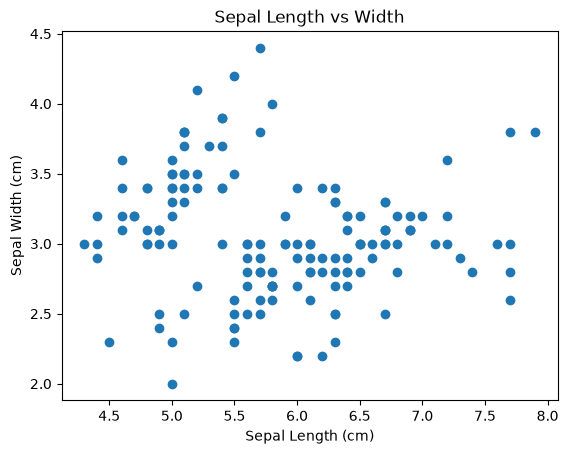

In [7]:
ax = plt.axes()

ax.scatter(data.sepal_length, data.sepal_width)

ax.set(
    xlabel='Sepal Length (cm)',
    ylabel='Sepal Width (cm)',
    title='Sepal Length vs Width'
);

### Упражнение 7: Подсчет частоты видов
    "Используйте специальный метод Pandas,
    чтобы узнать точное количество записей
    для каждого отдельного вида в очищенном наборе данных.

In [8]:
data.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Упражнение 8: Ускорение Scikit-learn с помощью Intel® Extension
    Напишите строки кода, которые необходимо выполнить сразу
    после импорта библиотеки `sklearn` для включения оптимизации oneDAL.

In [9]:
# модели из sklearn нужно импортировать уже после patch_sklearn(), иначе они останутся обычными
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


### Упражнение 9: Фреймворки в Machine Learning
    Основываясь на вводных материалах, объясните,
    почему фреймворки — это больше, чем просто библиотеки,
    и какую материальную пользу приносит оптимизация гиперпараметров.

#### Напишите ваш ответ в виде текстовой ячейки или комментария

Библиотека это набор готовых функций, которые вызывают по мере надобности: взял нужную и пошел дальше. Фреймворк задает общий порядок работы, и код пользователя встраивается в этот порядок. В scikit-learn любая модель устроена одинаково, сначала `fit()`, потом `predict()`, поэтому один алгоритм меняется на другой правкой одной строки. Кроме самих алгоритмов фреймворк дает все, что нужно вокруг них: разбиение выборки, масштабирование признаков, кросс-валидацию, метрики качества.

Гиперпараметры модель не подбирает сама, их задает человек до обучения: сколько соседей брать в k-NN, какой глубины строить дерево, сколько кластеров искать. Подбор таких значений (`GridSearchCV`, `RandomizedSearchCV`) это самый дешевый способ улучшить модель: данные и алгоритм те же, а точность выше. Заодно так контролируется переобучение и недообучение, потому что сложность модели тоже задается гиперпараметрами. А чем быстрее работает фреймворк (например, после `patch_sklearn()` из упражнения 8), тем больше вариантов можно перебрать за то же время.

### Упражнение 10: Предварительные требования курса
    Перечислите как минимум три базовых направления
    (в математике и программировании),
    необходимых для успешного прохождения курса по Machine Learning.

#### Напишите ваш ответ в виде текстовой ячейки или комментария

Во вводной части курса названы четыре предмета: программирование на Python, математический анализ, линейная алгебра и статистика.

## Упражнение 11: Продвинутая визуализация распределений с Matplotlib (Гистограммы)
    Используя Matplotlib, постройте фигуру с двумя подграфиками (subplots)
    рядом друг с другом (1 строка, 2 колонки):,
    - На первом графике отобразите гистограмму распределения для `petal_length`.,
    - На втором графике отобразите гистограмму распределения для `petal_width`.,
    Добавьте заголовки и подписи к осям для каждого графика.

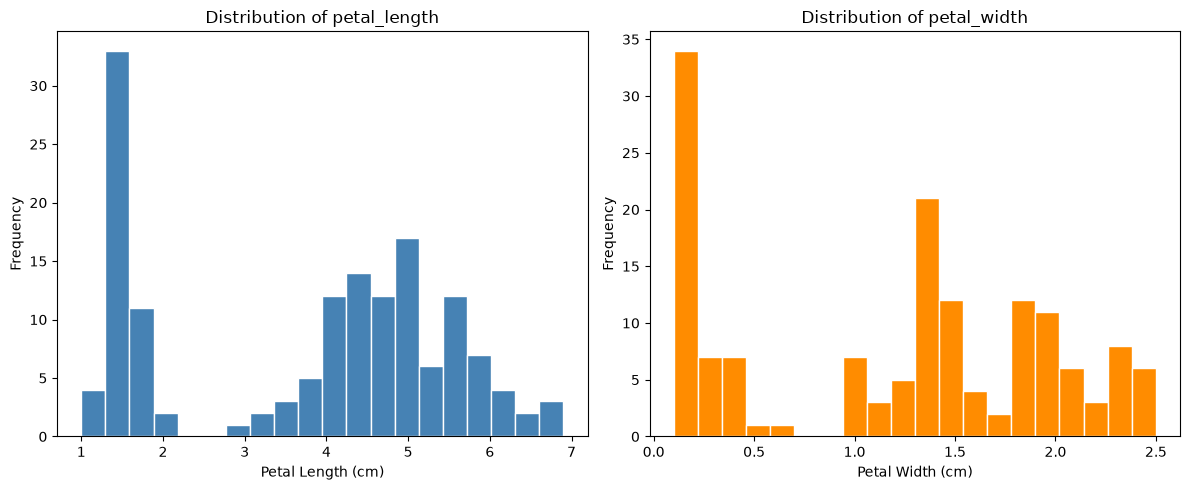

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(data.petal_length, bins=20, color='steelblue', edgecolor='white')
axes[0].set(xlabel='Petal Length (cm)',
            ylabel='Frequency',
            title='Distribution of petal_length')

axes[1].hist(data.petal_width, bins=20, color='darkorange', edgecolor='white')
axes[1].set(xlabel='Petal Width (cm)',
            ylabel='Frequency',
            title='Distribution of petal_width')

fig.tight_layout()

### Упражнение 12: Исследование данных с помощью Seaborn (Pairplot)
    Импортируйте библиотеку `seaborn`
    и постройте парную матрицу графиков (`sns.pairplot`)
    для всего набора данных Iris,
    раскрасив точки в зависимости от вида растения (`species`).

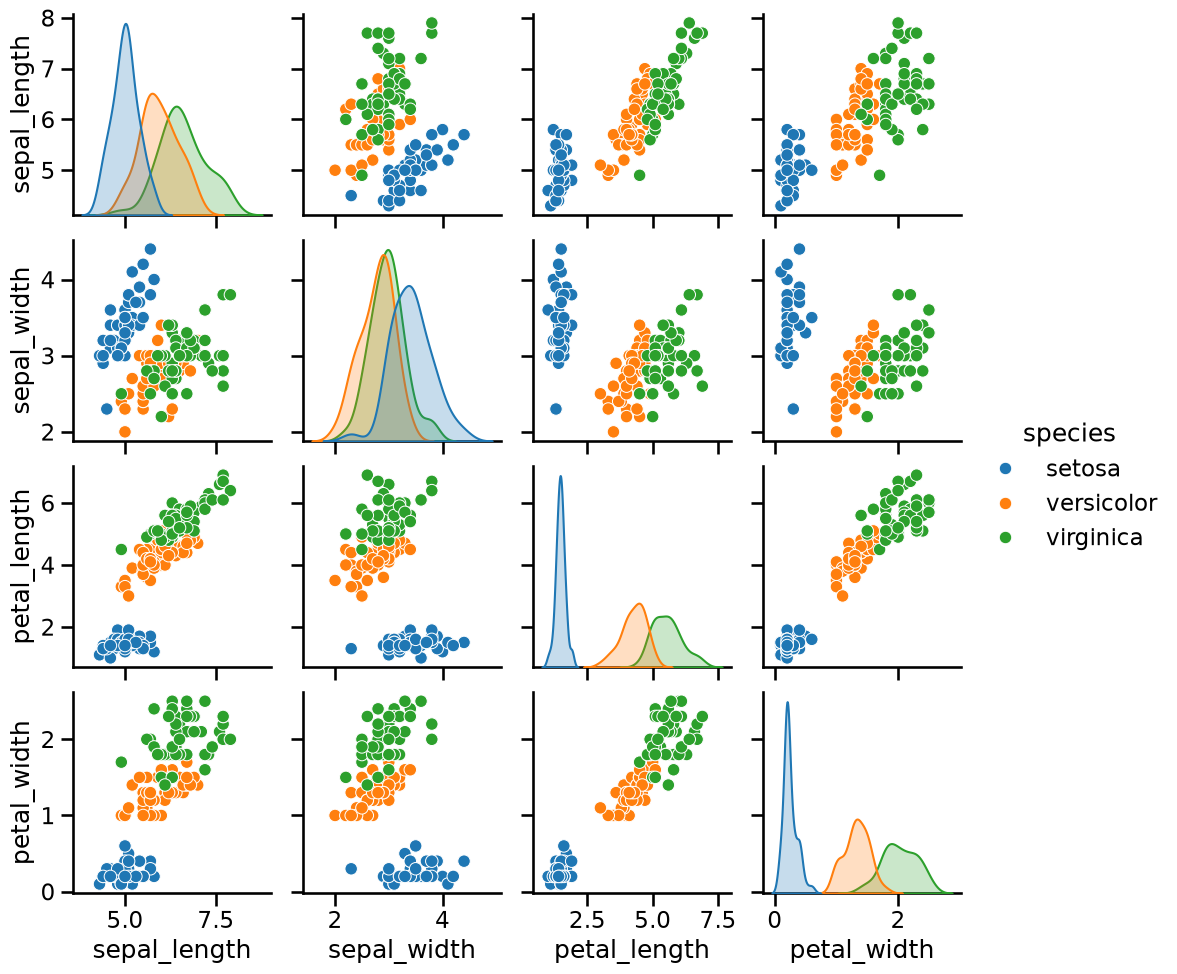

In [11]:
import seaborn as sns

sns.set_context('talk')
sns.pairplot(data, hue='species');

### Упражнение 13: Анализ выбросов через Boxplot (Seaborn)
    Используя библиотеку Seaborn, постройте график «ящик с усами» (`sns.boxplot`),
    чтобы сравнить распределение длины лепестков (`petal_length`) для каждого отдельного вида (`species`).

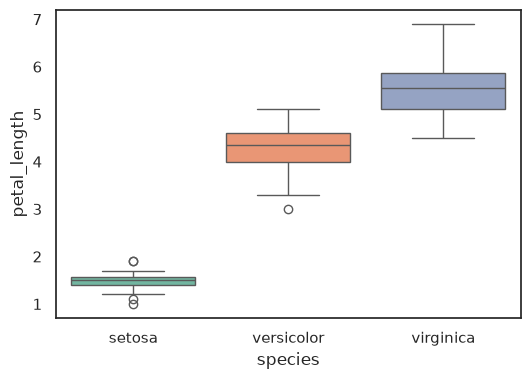

In [12]:
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
# hue='species' и legend=False, потому что palette без hue в новом seaborn дает предупреждение
sns.boxplot(data=data, x='species', y='petal_length', hue='species',
            palette='Set2', legend=False);

### Упражнение 14: Тепловая карта корреляций (Seaborn Heatmap)
    Вычислите корреляционную матрицу числовых признаков
    с помощью метода `corr()`, а затем визуализируйте её в виде тепловой карты (`sns.heatmap`),
    включив отображение числовых значений внутри ячеек (`annot=True`).

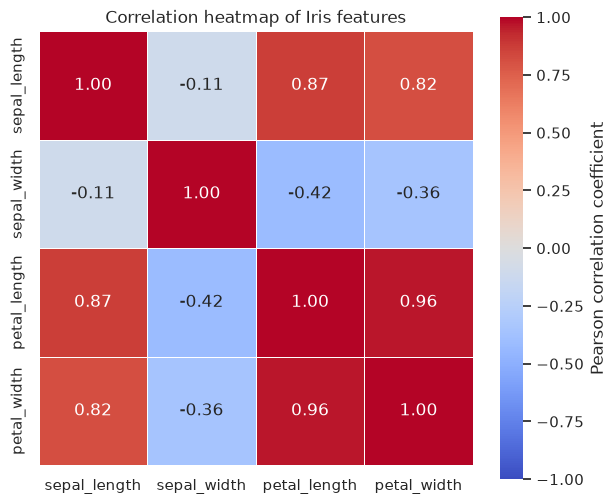

In [13]:
# species текстовая колонка, поэтому корреляцию считаем только по числовым
corr = data.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Pearson correlation coefficient'},
            ax=ax)

ax.set_title('Correlation heatmap of Iris features');